In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/digit-recognizer/sample_submission.csv
/kaggle/input/digit-recognizer/train.csv
/kaggle/input/digit-recognizer/test.csv


In [2]:
df = pd.read_csv('/kaggle/input/digit-recognizer/train.csv')

In [3]:
df.head()

,label,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
0,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [4]:
df.shape

(42000, 785)

In [5]:
df.sample(1)

,label,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
5166,9,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


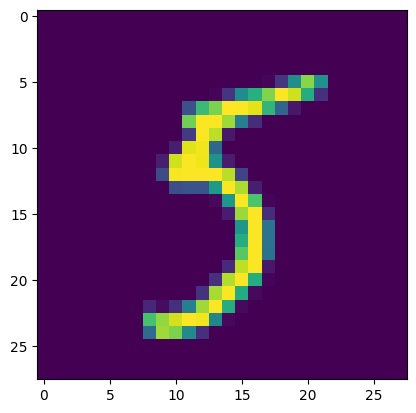

In [6]:
import matplotlib.pyplot as plt
plt.imshow(df.iloc[14745,1:].values.reshape(28, 28))

In [7]:
df.iloc[14745,1:]

pixel0      0
pixel1      0
pixel2      0
pixel3      0
pixel4      0
           ..
pixel779    0
pixel780    0
pixel781    0
pixel782    0
pixel783    0
Name: 14745, Length: 784, dtype: int64

In [8]:
x = df.iloc[:, 1:]
y = df.iloc[:, 0]

In [9]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state = 42)

In [10]:
x_train.shape

(33600, 784)

In [11]:
from sklearn.neighbors import KNeighborsClassifier

In [12]:
from sklearn.metrics import accuracy_score 
import time
knn = KNeighborsClassifier()
knn.fit(x_train, y_train)
start = time.time()
y_pred = knn.predict(x_test)
print("Time taken: ", time.time() - start)
print("Accuracy: ", accuracy_score(y_test, y_pred))

Time taken:  10.535918712615967
Accuracy:  0.9648809523809524


In [13]:
from sklearn.preprocessing import StandardScaler
std = StandardScaler()
x_train_scaled = std.fit_transform(x_train)
x_test_scaled = std.fit_transform(x_test)

In [14]:
from sklearn.decomposition import PCA
pca = PCA(n_components = 100)

In [15]:
x_train_pca = pca.fit_transform(x_train_scaled)
x_test_pca = pca.transform(x_test_scaled)

In [16]:
print(f"x_train shape: {x_train.shape}")
print(f"x_train_pca shape: {x_train_pca.shape}")

x_train shape: (33600, 784)
x_train_pca shape: (33600, 100)


In [17]:
knn2 = KNeighborsClassifier()
knn2.fit(x_train_pca, y_train)

KNeighborsClassifier()

In [18]:
start = time.time()
y_pred_pca = knn2.predict(x_test_pca)
print(f"Time taken: {time.time() - start}")
print(f"Accuracy: {accuracy_score(y_pred_pca, y_test)}")

Time taken: 1.7566251754760742
Accuracy: 0.955595238095238


 # VISUALIZATION

In [19]:
pcaVisualize = PCA(n_components = 2)

In [20]:
x_train_pca = pcaVisualize.fit_transform(x_train)
x_test_pca = pcaVisualize.transform(x_test)

In [21]:
x_train_pca

array([[-226.60523462, -305.89437099],
       [  38.33583717,  461.09152047],
       [-305.49225463,  351.67141678],
       ...,
       [ -28.00133402, -596.06287179],
       [ 233.97011308,  -18.64779077],
       [1096.50373629,  254.72333173]])

In [22]:
x_train_pca.shape

(33600, 2)

In [23]:
import plotly.express as px
fig = px.scatter(x = x_train_pca[:, 0], y = x_train_pca[:, 1], color = y_train)
fig.show()

In [24]:
pcaVisualize3D = PCA(n_components=3)
x_train_pca = pcaVisualize3D.fit_transform(x_train)
x_test_pca = pcaVisualize3D.transform(x_test)

In [25]:
x_train_pca

array([[-226.60523462, -305.89437099, -417.17563833],
       [  38.33583717,  461.09152047, -100.40840682],
       [-305.49225463,  351.67141678,  961.3475787 ],
       ...,
       [ -28.00133402, -596.06287179, -606.25130926],
       [ 233.97011308,  -18.64779077,  148.27481803],
       [1096.50373629,  254.72333173,  560.33354832]])

In [26]:
fig = px.scatter_3d(df, x = x_train_pca[:, 0], y = x_train_pca[:, 1], z = x_train_pca[:, 2], color = y_train)
# fig.update_layput(margin=dict(l = 20, r = 20, t = 20, b = 20))
fig.show()

In [27]:
pcaVisualize3D.components_
# eigen vectors

array([[-0., -0., -0., ..., -0., -0., -0.],
       [-0., -0., -0., ..., -0., -0., -0.],
       [-0., -0., -0., ..., -0., -0., -0.]])

In [28]:
pcaVisualize3D.explained_variance_
# eigen values

array([335506.57620544, 244807.10511442, 212051.0345165 ])

In [29]:
pcaVisualize3D.explained_variance_ratio_*100
# percentage of variance covered

array([9.77072202, 7.12934512, 6.17541312])

In [30]:
np.cumsum(pcaVisualize3D.explained_variance_ratio_*100)

#take till 90 % reached

array([ 9.77072202, 16.90006714, 23.07548025])

In [31]:
pcaAll = PCA(n_components=None)
x_train_pca = pcaAll.fit_transform(x_train)

In [32]:
pcaAll.components_.shape

(784, 784)

In [33]:
pcaAll.explained_variance_.shape

(784,)

In [34]:
np.cumsum(pcaAll.explained_variance_ratio_*100)

array([  9.77072202,  16.90006714,  23.07548025,  28.46503165,
        33.35758464,  37.69442897,  40.97100283,  43.86370553,
        46.63440853,  48.96358002,  51.05668653,  53.10385056,
        54.81164524,  56.49485131,  58.07957256,  59.56755523,
        60.89065341,  62.17459011,  63.3579737 ,  64.50916017,
        65.5851292 ,  66.60934439,  67.57597018,  68.49326656,
        69.37798098,  70.21150899,  71.0265796 ,  71.80191166,
        72.54389821,  73.23722344,  73.89807167,  74.53128116,
        75.13449417,  75.72322427,  76.28505433,  76.82491526,
        77.33282504,  77.81995201,  78.29120493,  78.75576135,
        79.20825126,  79.6523098 ,  80.06882806,  80.46446448,
        80.84806817,  81.22119574,  81.58190047,  81.93076548,
        82.26496516,  82.58297589,  82.89718078,  83.20441512,
        83.4967822 ,  83.78333605,  84.06245438,  84.33178296,
        84.5967122 ,  84.85335075,  85.10620403,  85.35145736,
        85.59200785,  85.83110508,  86.05799916,  86.27

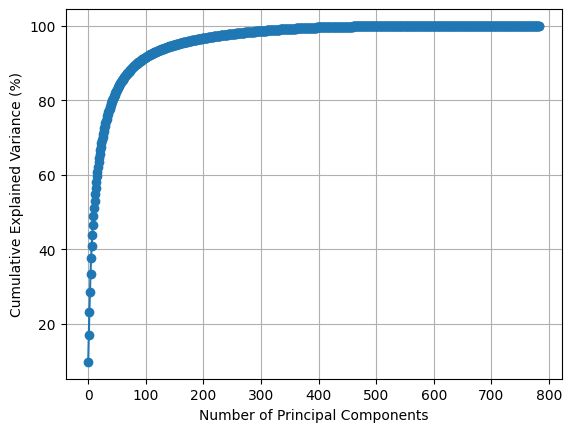

In [35]:
import matplotlib.pyplot as plt
plt.plot(
    np.cumsum(pcaAll.explained_variance_ratio_ * 100),
    marker='o'
)
plt.xlabel("Number of Principal Components")
plt.ylabel("Cumulative Explained Variance (%)")
plt.grid(True)
plt.show()